<a href="https://colab.research.google.com/github/Lamiya-56/Heart-Disease-Risk-Analysis/blob/main/Heart%20Disease%20Risk%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#**Data Profiling & Cleaning**

In [ ]:
df=pd.read_csv('/content/heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [ ]:
df.shape

(1025, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1020,True
1021,True
1022,True
1023,True


In [ ]:
duplicate_count=df.duplicated().sum()
print(f"Datasetdə {duplicate_count} dənə təkrarlanan sətir tapıldı.")

df.drop_duplicates(inplace=True)
print(f"Təmizləndikdən sonra datasetin ölçüsü: {df.shape}")

Datasetdə 723 dənə təkrarlanan sətir tapıldı.
Təmizləndikdən sonra datasetin ölçüsü: (302, 14)


In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Qan təzyiqi (Trestbps)
Orta göstərici 131.6-dır. Tibbi olaraq 120 normal sayılır, 140-dan yuxarı isə yüksək təzyiq (hipertoniya) hesab olunur.

İnsanların ən azı 25%-i (75%-lik kvartil 140-dır) yüksək qan təzyiqi ilə yaşayır. Bu da target (xəstəlik) ilə birbaşa əlaqəli ola biləcək vacib faktordur.

# **Demoqrafik Analiz (Demographic Analysis)**

***Burada əsas diqqət xəstələrin kimliyinə yönəlir.***

##1. Yaş Paylanması (Histogram)

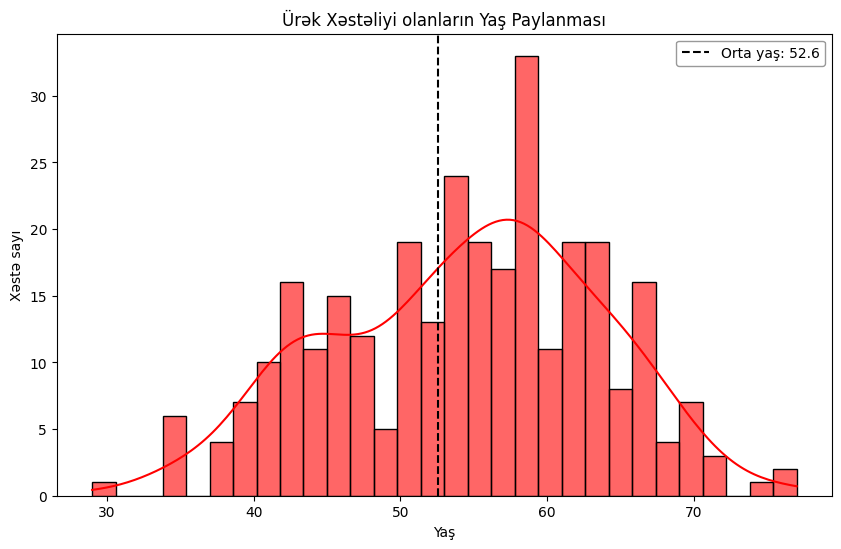

In [ ]:
# Yalnız ürək xəstəliyi olanları ayıraq
patients=df[df['target']==1]

plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True, color='red', alpha=0.6) # alpha-rengin canliliqina tesir edir, bins ise yaslari qruplara bolur, kde-smooth xett elave edir
plt.axvline(patients['age'].mean(), color='black', linestyle='--', label=f"Orta yaş: {patients['age'].mean():.1f}")

plt.title('Ürək Xəstəliyi olanların Yaş Paylanması')
plt.xlabel('Yaş')
plt.ylabel('Xəstə sayı')
plt.legend(frameon=True, facecolor='white', edgecolor='gray')

plt.show()

Risk Qrupu (Pik Nöqtəsi): Qrafikdə ən hündür sütun (pik) təxminən 58-60 yaş aralığına düşür. Bu o deməkdir ki, datasetdə ürək xəstəliyi diaqnozu qoyulanların ən böyük qrupu bu yaş aralığındakı şəxslərdir.

Erkən Risk: Maraqlıdır ki, xəstəlik yalnız yaşlılarda deyil, 40 yaşından etibarən ciddi artış göstərir. 40-45 yaş arası xəstə sayında gözlənilməz bir yüksəliş var.


##2. Cinsiyyət Faktoru (Gender Analysis)

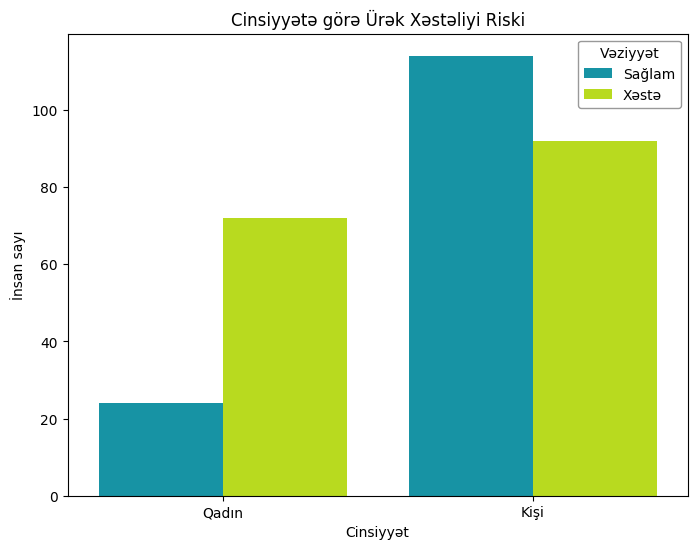

In [ ]:
plt.figure(figsize=(8, 6))

# Qrafiki qururuq
sns.countplot(x='sex', hue='target', data=df, palette='nipy_spectral') #hue parametri- hər sütunu diaqnoz statusuna görə 2 hissəyə bölür, target sutununda 2 hal movcuddur, xeste ve saqlarm, ona gore x deyeri ucun 2 bar yaranir

# X oxundakı 0 və 1-i adlandırıq
# Birinci siyahı [0, 1] mövqeləri, ikinci siyahı isə həmin mövqelərə verilən adlardır
plt.xticks([0, 1], ['Qadın', 'Kişi']) #0 və 1 rəqəmlərini dəyişir:
# 0 → Qadın
# 1 → Kişi

plt.title('Cinsiyyətə görə Ürək Xəstəliyi Riski')
plt.xlabel('Cinsiyyət')
plt.ylabel('İnsan sayı')
plt.legend(title='Vəziyyət', labels=['Sağlam', 'Xəstə'], frameon=True, facecolor='white', edgecolor='gray')

plt.show()

Qrafikə baxanda görürük ki, datasetdəki qadınların (0) böyük əksəriyyəti yaşıl barda, yəni "Xəstə" kateqoriyasındadır. Sağlam qadınların sayı xəstə olanlara nisbətən çox azdır. Bu o deməkdir ki, bu datasetə görə qadın olmaq ürək xəstəliyi riski ilə güclü şəkildə korrelyasiya edir.

Datada kişilərin sayı (təxminən 70%) qadınlardan daha çoxdur. Lakin qadınlar azlıq təşkil etsə də, onların daxilindəki xəstəlik faizi çox yüksəkdir.

##3. Yaş vs. Cinsiyyət (Violin Plot)

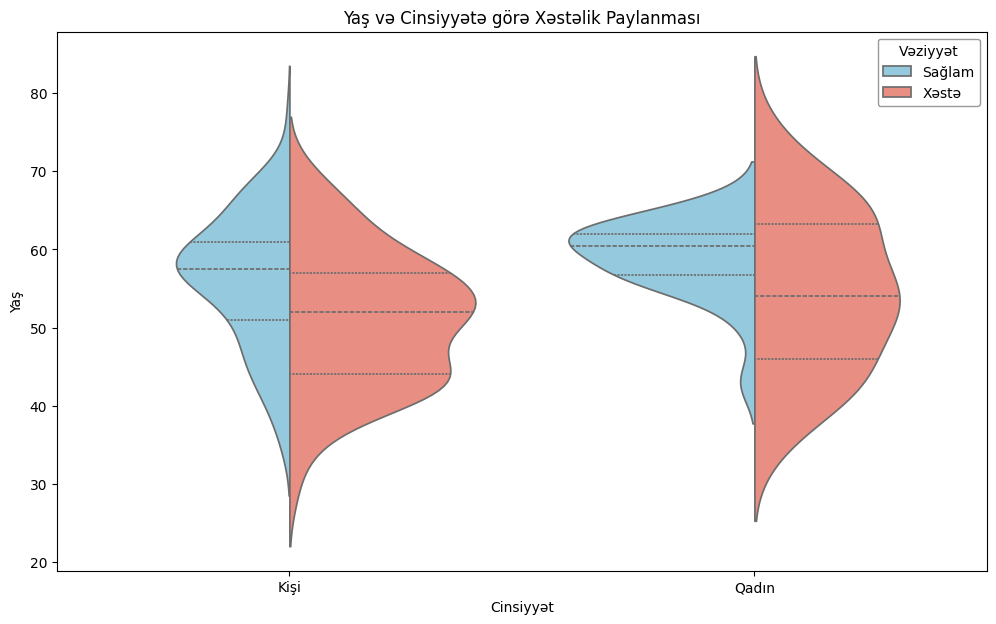

In [ ]:
# Datanı kopyalayırıq ki, orijinal data dəyişməsin
df_plot = df.copy()

# Rəqəmləri sözlərlə əvəz edirik
df_plot['target'] = df_plot['target'].map({0: 'Sağlam', 1: 'Xəstə'})
df_plot['sex'] = df_plot['sex'].map({0: 'Qadın', 1: 'Kişi'})

plt.figure(figsize=(12, 7))

# Qrafiki qururuq
# Artıq target sütununda sözlər olduğu üçün legend avtomatik düzələcək
sns.violinplot(x='sex', y='age', hue='target', data=df_plot,
               split=True, inner="quart", palette={"Sağlam": "skyblue", "Xəstə": "salmon"}) #inner=quart median ve kvartilleri gosterir

plt.title('Yaş və Cinsiyyətə görə Xəstəlik Paylanması')
plt.xlabel('Cinsiyyət')
plt.ylabel('Yaş')
plt.legend(title='Vəziyyət', frameon=True, facecolor='white', edgecolor='gray')

plt.show()

Qadınlar (Sağ tərəf):

Qadınlarda xəstə olanların (salmon) sıxlığı 50-65 yaş arasında çox genişdir.

Amma sağlam qadınlara (mavi) baxanda görürük ki, onlar əsasən 60 yaş civarında toplanıblar və 50 yaşdan aşağıda sağlam qadın demək olar ki, yoxdur.

Nəticə: Bu datasetə görə, 40-55 yaş arası qadınların demək olar ki, hamısı xəstə kateqoriyasındadır.

Qadınlar tərəfində mavi hissədəki 3 xətt bir-birinə çox yaxındır və yuxarıda (60 yaş civarı) toplanıb.

Insight: Sağlam qadınlar bu datasetdə çox dar bir yaş aralığında (təxminən 58-63 yaş) cəmləşib. Amma xəstə qadınların xətləri arasındakı məsafə daha böyükdür. Bu bizə deyir ki, xəstəlik qadınlarda çox geniş bir yaş spektrinə (45-dən 65-ə qədər) yayılıb.

---


Kişilər (Sol tərəf):

Xəstə kişilərin sıxlığı 40 yaşdan başlayaraq genişlənməyə başlayır və pik nöqtəsi 50-ə yaxın yaşlardadır.

Sağlam kişilər isə daha çox 55-65 yaş aralığında sıxlaşıb.

Nəticə: Kişilərdə xəstəlik daha erkən yaşlarda (40+) büruzə verir (sıxlıq artır), sağlam olanlar isə daha yaşlı qrupdur.


---
Ümumi Trend:

Hər iki cinsiyyətdə də xəstəlik olan hissənin (salmon) "genişliyi" daha aşağıdadır. Bu, bizim əvvəlki hipotezimizi təsdiqləyir: Xəstə olanlar, sağlam olanlardan daha gəncdir.

In [ ]:
df_plot

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,Kişi,0,125,212,0,1,168,0,1.0,2,2,3,Sağlam
1,53,Kişi,0,140,203,1,0,155,1,3.1,0,0,3,Sağlam
2,70,Kişi,0,145,174,0,1,125,1,2.6,0,0,3,Sağlam
3,61,Kişi,0,148,203,0,1,161,0,0.0,2,1,3,Sağlam
4,62,Qadın,0,138,294,1,1,106,0,1.9,1,3,2,Sağlam
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,Qadın,2,120,211,0,0,115,0,1.5,1,0,2,Xəstə
733,44,Qadın,2,108,141,0,1,175,0,0.6,1,0,2,Xəstə
739,52,Kişi,0,128,255,0,1,161,1,0.0,2,1,3,Sağlam
843,59,Kişi,3,160,273,0,0,125,0,0.0,2,0,2,Sağlam


#**Tibbi Göstəricilərin Analizi (Clinical Metrics Analysis)**

***Bu hissədə bioloji faktorların xəstəliyə təsirini araşdırdım.***

##1.Xolesterin və Təzyiq: Aralarındakı əlaqə (Scatter Plot)

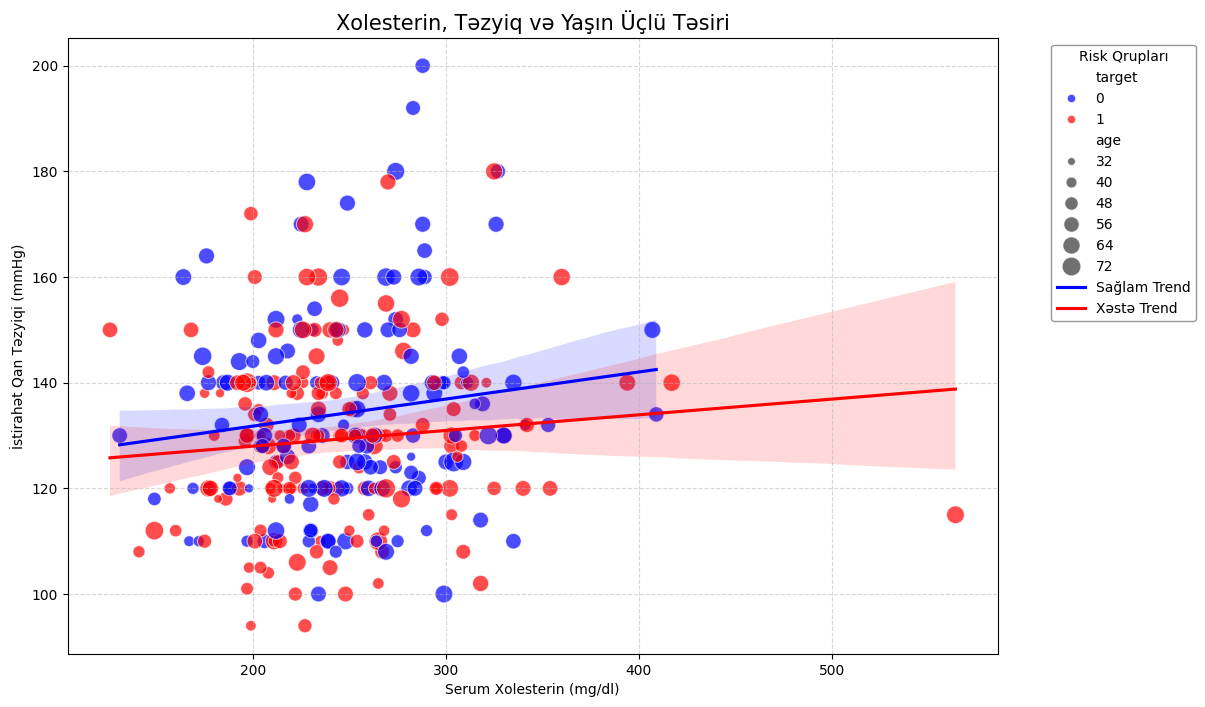

In [ ]:
plt.figure(figsize=(12, 8))

# sns.scatterplot-dan istifadə edərək kompleks vizual yaradırıq
scatter = sns.scatterplot(
    data=df,
    x='chol',
    y='trestbps',
    size='age',   # Yaş artdıqca qabarcıqlar böyüyür
    hue='target',  # Xəstə (1) vs Sağlam (0)
    sizes=(20, 200),  # Qabarcıqların ölçü aralığı
    palette={0: 'blue', 1: 'red'},
    alpha=0.7
)

# Trendi görmək üçün xətlər (hər qrup üçün ayrı)
sns.regplot(data=df[df['target']==0], x='chol', y='trestbps', scatter=False, color='blue', label='Sağlam Trend')
sns.regplot(data=df[df['target']==1], x='chol', y='trestbps', scatter=False, color='red', label='Xəstə Trend')

plt.title('Xolesterin, Təzyiq və Yaşın Üçlü Təsiri', fontsize=15)
plt.xlabel('Serum Xolesterin (mg/dl)')
plt.ylabel('İstirahət Qan Təzyiqi (mmHg)')
plt.legend(title="Risk Qrupları", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, facecolor='white', edgecolor='gray')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Ürək xəstəliyi olan şəxslərdə təzyiqin yüksək olması üçün mütləq xolesterinin də çox yüksək olmasına ehtiyac qalmır. Məsələn:

Damar elastikliyi: Xəstə şəxsin damarları artıq zədələnibsə, xolesterini normal olsa belə, təzyiqi yüksək ola bilər.

Dərman müdaxiləsi: Ürək xəstələri çox vaxt təzyiq və ya xolesterin salan dərmanlar qəbul edirlər. Bu dərmanlar xolesterin və təzyiq arasındakı o təbii "zənciri" qırır. Ona görə də qrafikdə xolesterin artsa da, təzyiqin o qədər də kəskin artmadığını görürük.

---



Yaş Faktoru (Qabarcıqların ölçüsü)
Qrafikdəki dairələrin ölçüsü böyüdükcə yaş artır.

Insight: Diqqət yetirsək, qrafikin yuxarı hissələrində (yüksək təzyiq zonası, 160-200 mmHg) dairələr daha böyükdür. Bu, yaş artdıqca yüksək qan təzyiqi riskinin artdığını aydın şəkildə göstərir. Kiçik dairələr (gənclər) daha çox aşağı və orta təzyiq zonalarında sıxlaşıb.


---

Xolesterin "Anomaliyası" (Outlier)
X oxunun ən sağında, 564 dəyərində tənha bir qırmızı nöqtə var.

Insight: Bu şəxs çox yüksək xolesterinə malikdir, lakin maraqlıdır ki, onun qan təzyiqi (təxminən 120) normadadır. Bu, "yüksək xolesterin hər zaman yüksək təzyiq demək deyil" fikrini vizual olaraq sübut edir.



---



Məlumatların ən çox toplandığı yer 200-300 xolesterin və 120-140 təzyiq aralığıdır.

Insight: Bu zonada qırmızı və mavi nöqtələr bir-birinə çox qarışıb. Bu o deməkdir ki, təzyiq və xolesterin təkbaşına kimin xəstə, kimin sağlam olduğunu ayırd etmək üçün yetərli deyil. Modelin bu qrupu ayırmaq üçün digər sütunlara (məsələn, cp - sinə ağrısı növü) ehtiyacı olacaq.

##2.Maksimum Ürək Döyüntüsü (Thalach)

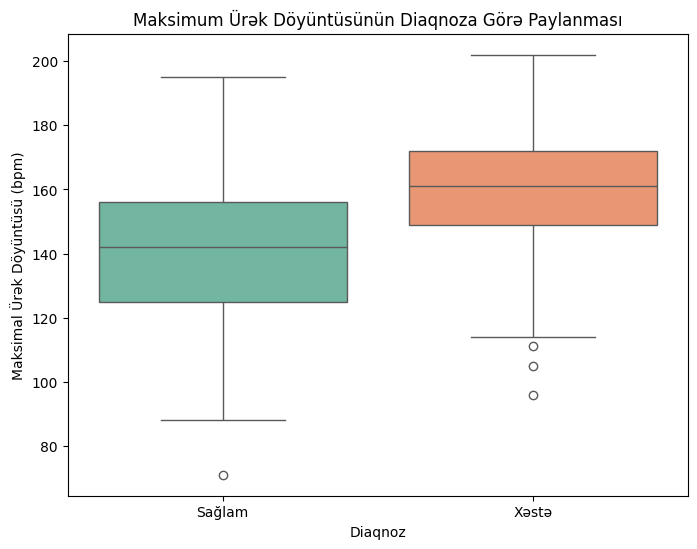

In [ ]:
plt.figure(figsize=(8, 6))

# Xəbərdarlığı aradan qaldırmaq üçün:
# 1. 'hue' parametrini də 'target' olaraq təyin edirik
# 2. 'legend=False' yazırıq ki, artıq eyni olan məlumat üçün əlavə qutu açılmasın
sns.boxplot(x='target', y='thalach', data=df, hue='target', palette='Set2', legend=False)

plt.xticks([0, 1], ['Sağlam', 'Xəstə'])
plt.title('Maksimum Ürək Döyüntüsünün Diaqnoza Görə Paylanması')
plt.xlabel('Diaqnoz')
plt.ylabel('Maksimal Ürək Döyüntüsü (bpm)')

plt.show()

Median Fərqi (Ortadakı xətlər)
Sağlam: Median təxminən 140 bpm civarındadır.

Xəstə: Median xeyli yüksəkdir — təxminən 160 bpm civarında.

Insight: Ürək xəstəliyi olan şəxslərin maksimum ürək döyüntüsü sağlam şəxslərdən orta hesabla 20 vahid daha yüksəkdir.



---

Outliers

Hər iki qrupda aşağı hissələrdə bir neçə nöqtə görürük:

Xəstə qrupunda bir neçə nəfər var ki, ürək döyüntüləri 120-dən aşağıdır (normaldan çox azdır).

Sağlam qrupda isə bir nəfərin döyüntüsü 80-dən də aşağıdır.

Insight: Bu insanlar "istisna" hallardır. Məsələn, xəstə qrupundakı o "aşağı döyüntülü" şəxslərin bəlkə də ürək blokadası və ya fərqli bir problemi var. Amma ümumi kütlə üçün thalach yüksəkliyi xəstəlik əlamətidir.

##3.Şəkər (Fbs):

Şəkəri yüksək olanların 51.11%-i ürək xəstəsidir.


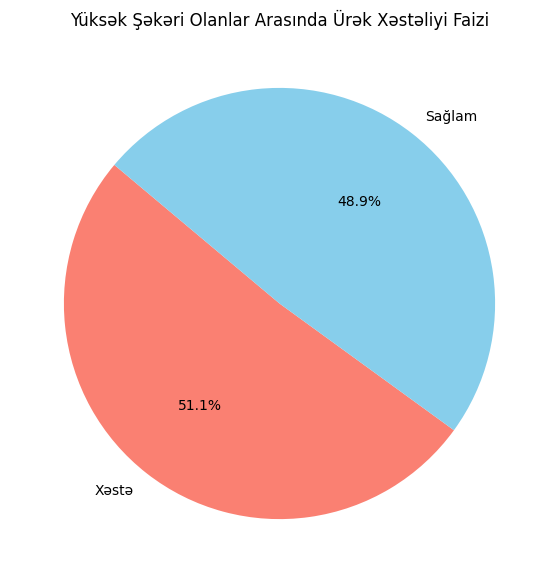

In [ ]:
# Yalnız şəkəri yüksək olanları (fbs=1) seçirik
high_fbs = df[df['fbs'] == 1]

# Onların içində xəstə olanların sayını tapırıq
counts = high_fbs['target'].value_counts(normalize=True) * 100

print(f"Şəkəri yüksək olanların {counts[1]:.2f}%-i ürək xəstəsidir.")

plt.figure(figsize=(7, 7))
plt.pie(counts, labels=['Xəstə', 'Sağlam'], autopct='%1.1f%%', colors=['salmon', 'skyblue'], startangle=140) #startangle qrafiki bir az çevirir (vizual üçün)
plt.title('Yüksək Şəkəri Olanlar Arasında Ürək Xəstəliyi Faizi')
plt.show()

In [ ]:
counts

,proportion
target,
1,51.111111
0,48.888889


Qrafikdə xəstə (51.1%) və sağlam (48.9%) nisbətinin demək olar ki, yarı-yarıya olduğunu görürük.

Insight: Əgər bir insanın qan şəkəri yüksəkdirsə (fbs > 120 mg/dl), bu onun mütləq ürək xəstəsi olduğu mənasına gəlmir. Şəkəri yüksək olanlar arasında xəstə olanların faizi (51.1%), ümumi datasetdəki xəstəlik faizinə (54%) çox yaxındır. Bu

#**Ürək Ağrısı və Simptomların Analizi (Symptom & ECG Analysis)**

***Burada xəstəliyin özünü necə büruzə verdiyini analiz etdim.***

##Chest Pain Type (Sinə ağrısı növü)

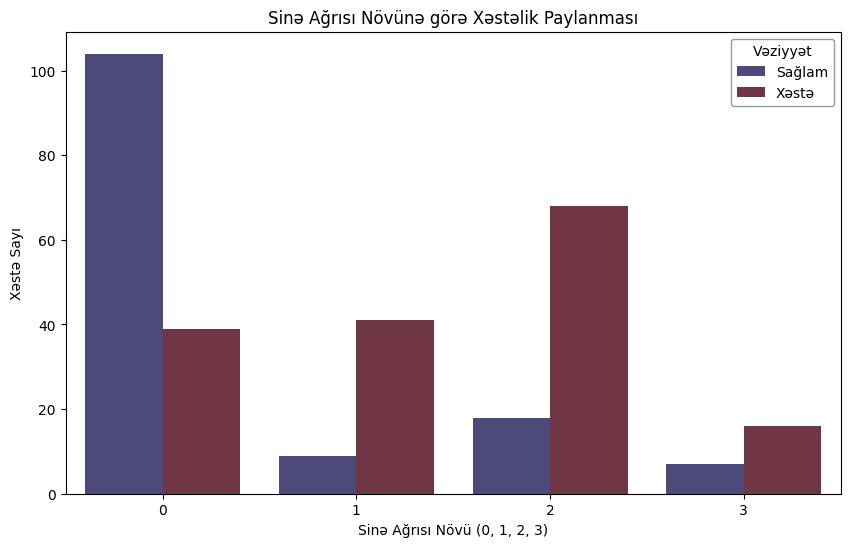

In [ ]:
plt.figure(figsize=(10, 6))

# CP sütununa görə qruplaşdırma
ax = sns.countplot(x='cp', hue='target', data=df, palette='icefire')

plt.title('Sinə Ağrısı Növünə görə Xəstəlik Paylanması')
plt.xlabel('Sinə Ağrısı Növü (0, 1, 2, 3)')
plt.ylabel('Xəstə Sayı')
plt.legend(title='Vəziyyət', labels=['Sağlam', 'Xəstə'], frameon=True, facecolor='white', edgecolor='gray')

plt.show()

0: Tipik Angina (Typical Angina)
Bu, ürək əzələsinə kifayət qədər qan getmədikdə baş verən klassik sinə ağrısıdır. Adətən fiziki gərginlik və ya emosional stress zamanı yaranır.

1: Atipik Angina (Atypical Angina)
Bu ağrı da ürəklə bağlı ola bilər, lakin klassik angina əlamətlərini tam göstərmir. Məsələn, ağrı sinədə yox, çiyində və ya kürəkdə hiss oluna bilər və ya fərqli şəkildə təzahür edir.

2: Qeyri-anginal Ağrı (Non-anginal Pain)
Bu tip ağrılar adətən ürək problemləri ilə birbaşa əlaqəli olmayan, daha çox əzələ-sümük sistemi və ya mədə-bağırsaq problemlərindən qaynaqlanan sinə ağrılarıdır.

3: Asimptomatik (Asymptomatic)
Xəstədə hər hansı bir nəzərə çarpan ağrı və ya narahatlıq simptomu yoxdur, lakin digər müayinələr (məsələn, EKQ) ürəkdə problem olduğunu göstərə bilər.

Sinə Ağrısı Növü (cp) Analizi
Bu qrafikdə ən diqqətçəkən məqam "0" növü (adətən asimptomatik və ya tipik olmayan ağrı) ilə digərləri arasındakı kəskin fərqdir.

Tip 0 (Ən böyük qrup): Burada sağlam insanların (göy bar) sayı xəstələrdən (tünd qırmızı) qat-qat çoxdur. Deməli, bu növ ağrısı olanların çoxu əslində ürək xəstəsi deyil.

Tip 1, 2 və 3: Bu kateqoriyalarda mənzərə tam tərsinə dəyişir. Xüsusilə Tip 2-də xəstə insanların sayı sağlamlardan dəfələrlə çoxdur.

Insight: Əgər bir pasiyentdə 1, 2 və ya 3-cü növ sinə ağrısı varsa, onun ürək xəstəsi olma ehtimalı statistik olaraq çox yüksəkdir. Bu, modelin üçün çox güclü bir proqnozlaşdırıcıdır.

##Hərəkət faktoru (Exang)

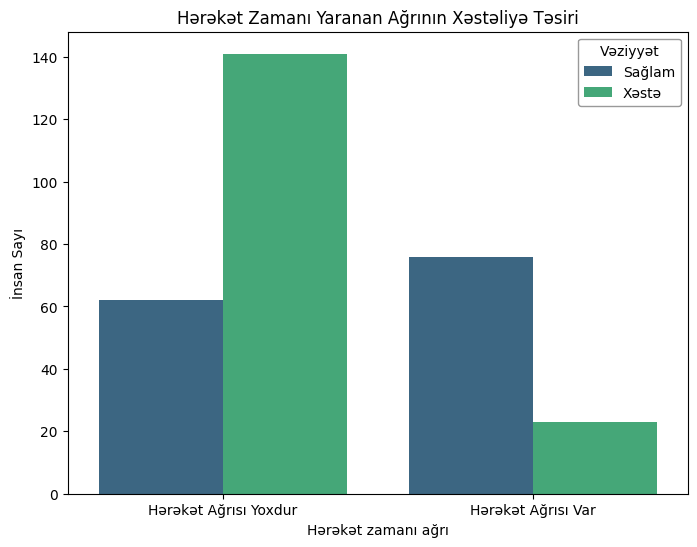

In [ ]:
plt.figure(figsize=(8, 6))

# exang: 1 = bəli (ağrı var), 0 = xeyr (ağrı yoxdur)
sns.countplot(x='exang', hue='target', data=df, palette='viridis')

plt.xticks([0, 1], ['Hərəkət Ağrısı Yoxdur', 'Hərəkət Ağrısı Var'])
plt.title('Hərəkət Zamanı Yaranan Ağrının Xəstəliyə Təsiri')
plt.xlabel('Hərəkət zamanı ağrı')
plt.ylabel('İnsan Sayı')
plt.legend(title='Vəziyyət', labels=['Sağlam', 'Xəstə'], frameon=True, facecolor='white', edgecolor='gray')

plt.show()

Bu qrafik "Hərəkət zamanı yaranan sinə ağrısı" (Exercise Induced Angina) ilə diaqnoz arasındakı əlaqəni göstərir və nəticə çox təəccüblüdür.

Hərəkət Ağrısı Yoxdur (0): Maraqlıdır ki, hərəkət zamanı sinə ağrısı olmayanlar arasında xəstə sayı (yaşıl bar) sağlamlardan çoxdur.

Hərəkət Ağrısı Var (1): Sinəsi hərəkət zamanı ağrıyanların böyük əksəriyyəti isə sağlam çıxıb.

Insight: Bu, ilk baxışda məntiqsiz görünə bilər, amma tibbi datasetlərdə tez-tez rast gəlinən bir haldır. Bu o deməkdir ki, bu datasetdəki ürək xəstələrinin çoxu "sakit" (anginasız) xəstəlik keçirənlərdir. Hərəkət zamanı ağrısı olanlar isə çox vaxt başqa səbəblərdən (məsələn, əzələ ağrısı) şikayət edirlər.

##EKQ nəticələri

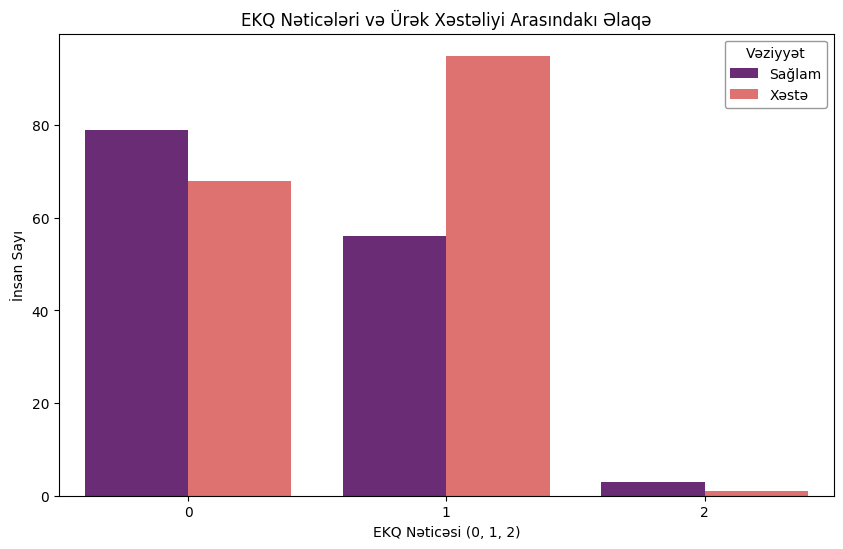

In [ ]:
plt.figure(figsize=(10, 6))

# restecg: 0 = Normal, 1 = ST-T dalğası anormallığı, 2 = Sol mədəcik hipertrofiyası
sns.countplot(x='restecg', hue='target', data=df, palette='magma')

plt.title('EKQ Nəticələri və Ürək Xəstəliyi Arasındakı Əlaqə')
plt.xlabel('EKQ Nəticəsi (0, 1, 2)')
plt.ylabel('İnsan Sayı')
plt.legend(title='Vəziyyət', labels=['Sağlam', 'Xəstə'], frameon=True, facecolor='white', edgecolor='gray')

plt.show()

EKG (Elektrokardioqram)
0 = Normal, 1 = ST-T dalğası anormallığı, 2 = Sol mədəcik hipertrofiyası

ST-T Dalğası Anormallığı (1) - Ən Böyük Risk Göstəricisi

Fakt: EKQ nəticəsi 1 olan insanlar arasında xəstə olanların (salmon rəngi) sayı, sağlam olanlardan (tünd bənövşəyi) demək olar ki, iki dəfə çoxdur.

Insight: Bu, diaqnoz üçün çox güclü bir proqnozlaşdırıcıdır. Əgər EKQ-də ST-T dalğası anormallığı aşkar edilibsə, bu, ürək xəstəliyinin mövcudluğuna dair çox ciddi bir xəbərdarlıqdır.

Normal EKQ (0) - Hər Şey Yaxşı Demək Deyil

0-cı sütuna baxdıqda görürük ki, EKQ-si normal çıxanlar arasında sağlamlar üstünlük təşkil etsə də, xəstə sayı hələ də kifayət qədər yüksəkdir (təxminən 70 nəfərə yaxın).

Insight: Bu o deməkdir ki, təkbaşına EKQ-nin normal olması insanın sağlam olduğunu tam zəmanət altına almır. Bu datasetdə bir çox insan var ki, istirahət halında EKQ-ləri normaldır, lakin digər testlərdə (məsələn, sinə ağrısı növü və ya maksimum ürək döyüntüsü) problem üzə çıxır.

Sol Mədəcik Hipertrofiyası (2) - Məlumat Azlığı

Burada barlar o qədər kiçikdir ki, demək olar ki, görünmür.

Insight: Bu vəziyyət datasetdə çox nadir rast gəlinir. Statistika baxımından bu qrup haqqında dəqiq bir hökm vermək çətindir (çünki adam sayı çox azdır), lakin mövcud az sayda insan arasında sağlam və xəstə nisbəti demək olar ki, bərabərdir.

#**Korrelyasiya Analizi (Correlation Analysis)**

In [ ]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trestbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalach,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exang,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


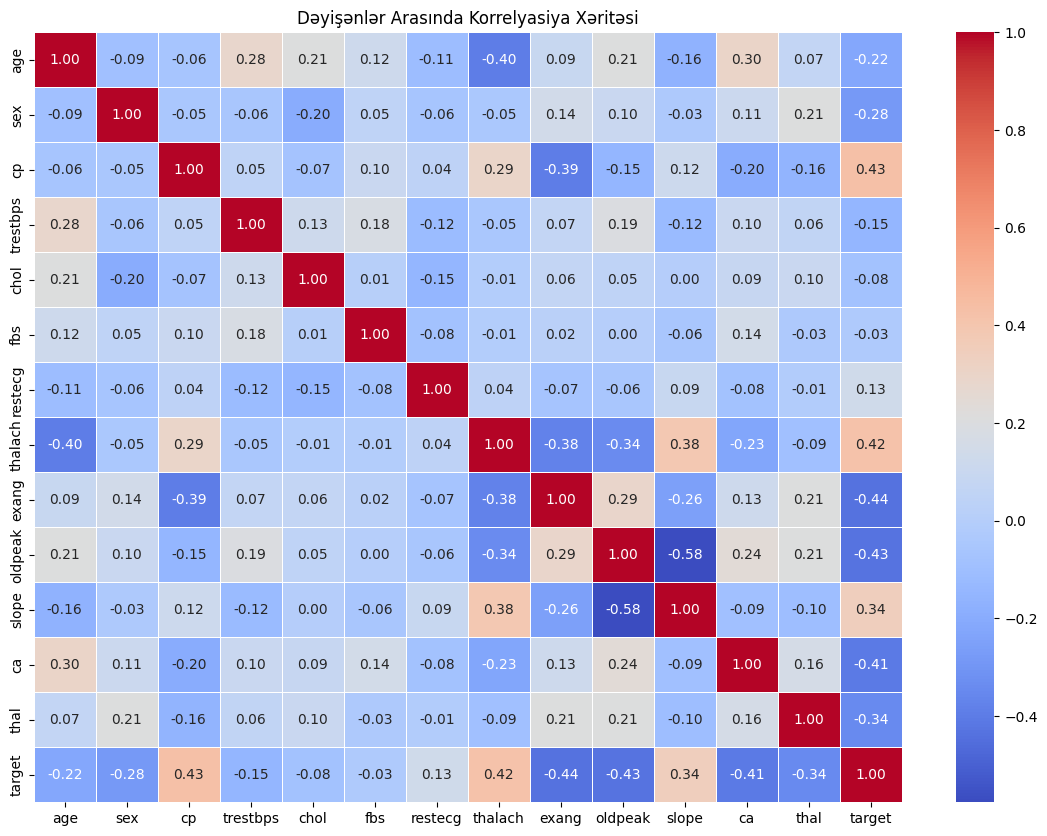

In [ ]:
plt.figure(figsize=(14, 10))

# Korrelyasiya matrisini hesablayırıq
correlation_matrix = df.corr()

# İstilik xəritəsini çəkirik
# annot=True hər xanadakı rəqəmi göstərir, cmap='coolwarm' isə müsbət və mənfi əlaqələri rənglərlə ayırır
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Dəyişənlər Arasında Korrelyasiya Xəritəsi')
plt.show()

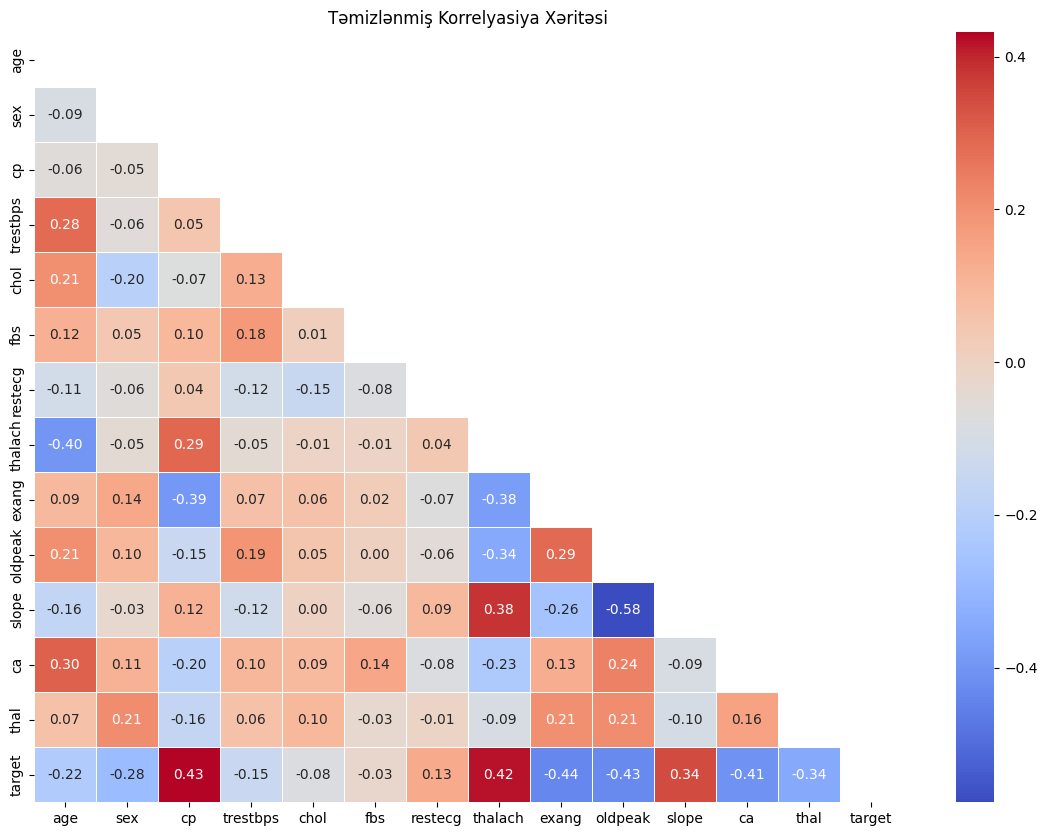

In [ ]:
import numpy as np

# 1. Korrelyasiya matrisini hesablayırıq
corr = df.corr()

# 2. Mask yaratmaq (Yalnız aşağı üçbucaqlı hissəni saxlamaq üçün)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))

# 3. Heatmap-ə 'mask' parametrini əlavə edirik
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Təmizlənmiş Korrelyasiya Xəritəsi')
plt.show()

Maksimum Ürək Döyüntüsü (thalach) və Diaqnoz (target) — Korrelyasiya: 0.42

Ürək döyüntüsü yüksək olan şəxslərdə xəstəlik aşkar edilmə faizi daha yüksəkdir.

Tibbi izah: Ürək zəiflədikdə və ya damarlar daraldıqda, bədəni lazımi miqdarda qanla təmin etmək üçün ürək daha sürətlə döyünməyə məcbur olur. Yəni yüksək thalach əslində ürəyin "stress" altında işlədiyinin göstəricisidir.

/tmp/ipykernel_12133/2117175697.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_risk = df.groupby(['age_group', 'target']).size().unstack()


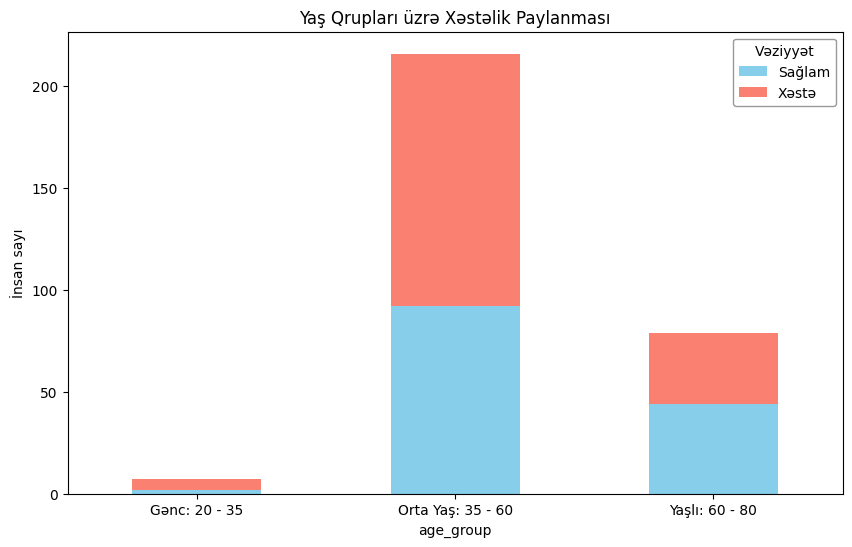

In [ ]:
# Yaş qrupları (əvvəlki kimi)
df['age_group'] = pd.cut(df['age'], bins=[20, 35, 60, 80], labels=['Gənc: 20 - 35', 'Orta Yaş: 35 - 60', 'Yaşlı: 60 - 80'])

# Qruplaşdırma
age_risk = df.groupby(['age_group', 'target']).size().unstack()

# Vizual: Stacked Bar Chart
age_risk.plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('Yaş Qrupları üzrə Xəstəlik Paylanması')
plt.ylabel('İnsan sayı')
plt.xticks(rotation=0)
plt.legend(title='Vəziyyət', labels=['Sağlam', 'Xəstə'], frameon=True, facecolor='white', edgecolor='gray')
plt.show()

Gənc (20-35): Bu qrupda insan sayı o qədər azdır ki, statistik analiz üçün demək olar ki, çəki kəsb etmir.

Orta Yaş (35-60): Datasetin əsas nüvəsi buradadır. Maraqlıdır ki, bu yaş qrupunda Xəstə sayı Sağlam sayından xeyli çoxdur.

Yaşlı (60-80): Burada isə nisbət demək olar ki, bərabərdir və ya sağlamların payı bir qədər artıb.

In [ ]:
df['age_group']

,age_group
0,Orta Yaş: 35 - 60
1,Orta Yaş: 35 - 60
2,Yaşlı: 60 - 80
3,Yaşlı: 60 - 80
4,Yaşlı: 60 - 80
...,...
723,Yaşlı: 60 - 80
733,Orta Yaş: 35 - 60
739,Orta Yaş: 35 - 60
843,Orta Yaş: 35 - 60


In [ ]:
df['age'].max()

77

In [ ]:
df_plot

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,Kişi,0,125,212,0,1,168,0,1.0,2,2,3,Sağlam
1,53,Kişi,0,140,203,1,0,155,1,3.1,0,0,3,Sağlam
2,70,Kişi,0,145,174,0,1,125,1,2.6,0,0,3,Sağlam
3,61,Kişi,0,148,203,0,1,161,0,0.0,2,1,3,Sağlam
4,62,Qadın,0,138,294,1,1,106,0,1.9,1,3,2,Sağlam
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,Qadın,2,120,211,0,0,115,0,1.5,1,0,2,Xəstə
733,44,Qadın,2,108,141,0,1,175,0,0.6,1,0,2,Xəstə
739,52,Kişi,0,128,255,0,1,161,1,0.0,2,1,3,Sağlam
843,59,Kişi,3,160,273,0,0,125,0,0.0,2,0,2,Sağlam


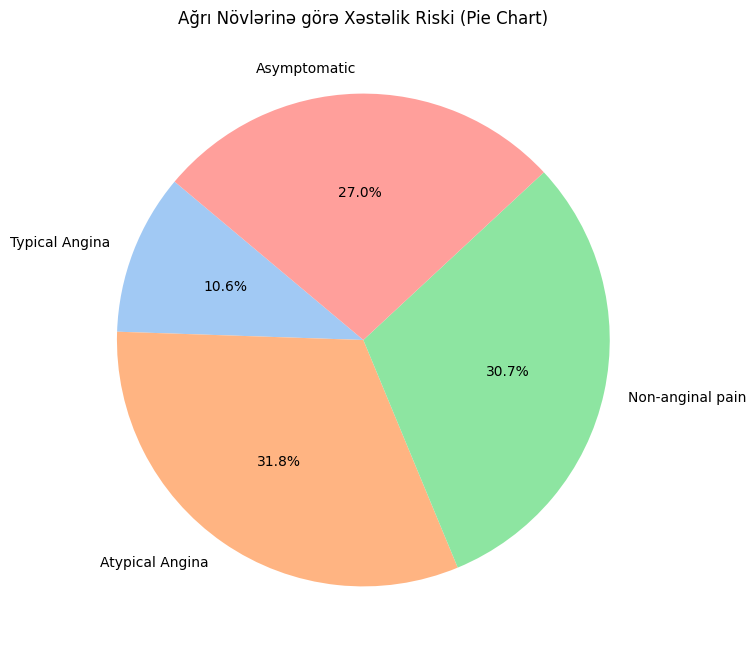

In [ ]:
cp_counts = df.groupby('cp')['target'].mean() * 100

plt.figure(figsize=(8, 8))

# Pie Chart-ın qurulması
plt.pie(cp_counts,
        labels=['Typical Angina', 'Atypical Angina', 'Non-anginal pain', 'Asymptomatic'],
        autopct='%1.1f%%',
        colors=sns.color_palette('pastel'),
        startangle=140)

plt.title('Ağrı Növlərinə görə Xəstəlik Riski (Pie Chart)')
plt.show()

Hamının "ürək ağrısı" dediyi Typical Angina bu qrafikdə ən kiçik hissədir.

Nəticə: Bu o deməkdir ki, kəskin ürək ağrısı ilə xəstəxanaya gələnlərin bir çoxu əslində başqa bir səbəbdən (məsələn, panik atak və ya əzələ ağrısı) qorxub gəliblər. Xəstəlik çıxanların içində bu ağrı növü çox azlıq təşkil edir.

/tmp/ipykernel_12133/634734293.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_df = df.groupby(['age_group', 'cp'])['target'].mean().unstack() * 100


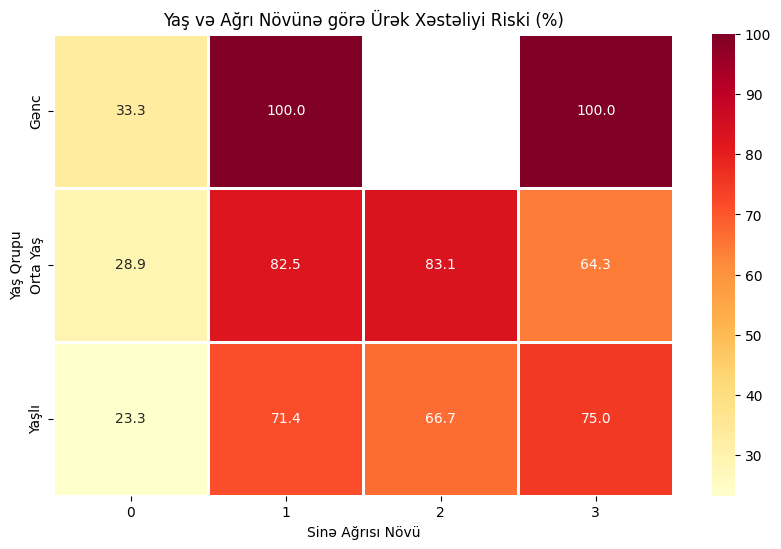

In [ ]:
# 1. Yaş qruplarını yaradırıq
df['age_group'] = pd.cut(df['age'], bins=[20, 35, 60, 80], labels=['Gənc', 'Orta Yaş', 'Yaşlı'])

# 2. İki kateqoriyalı qruplaşdırma və riskin hesablanması
pivot_df = df.groupby(['age_group', 'cp'])['target'].mean().unstack() * 100

# 3. Vizual: Heatmap (Risk xəritəsi)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, cmap='YlOrRd', fmt='.1f', linewidths=1)

plt.title('Yaş və Ağrı Növünə görə Ürək Xəstəliyi Riski (%)')
plt.xlabel('Sinə Ağrısı Növü')
plt.ylabel('Yaş Qrupu')
plt.show()

Gənclər Qrupundakı "100%" Riski
Gənc qrupunda (yuxarı sətir) Sinə Ağrısı Növü 1 və 3 olan hər kəs xəstə çıxıb (100.0).

Analitik Şərh: Bayaq yaş qrafikində qeyd etdiyimiz kimi, bu datasetdəki gənclər təsadüfi seçilməyib. Əgər bir gəncin spesifik sinə ağrısı varsa, bu datasetdə o mütləq xəstə kimi qeyd olunub.

Orta Yaş və "Gizli" Ağrılar

Orta yaş qrupunda 1 (Atypical) və 2 (Non-anginal) növ ağrılar 80%-dən çox risk daşıyır.